In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [7]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120 

try:
    df = pd.read_csv('resultados_aps_mochila.csv')
except FileNotFoundError:
    print("Erro: O arquivo 'resultados_aps_mochila.csv' não foi encontrado na pasta atual.")
    df = None

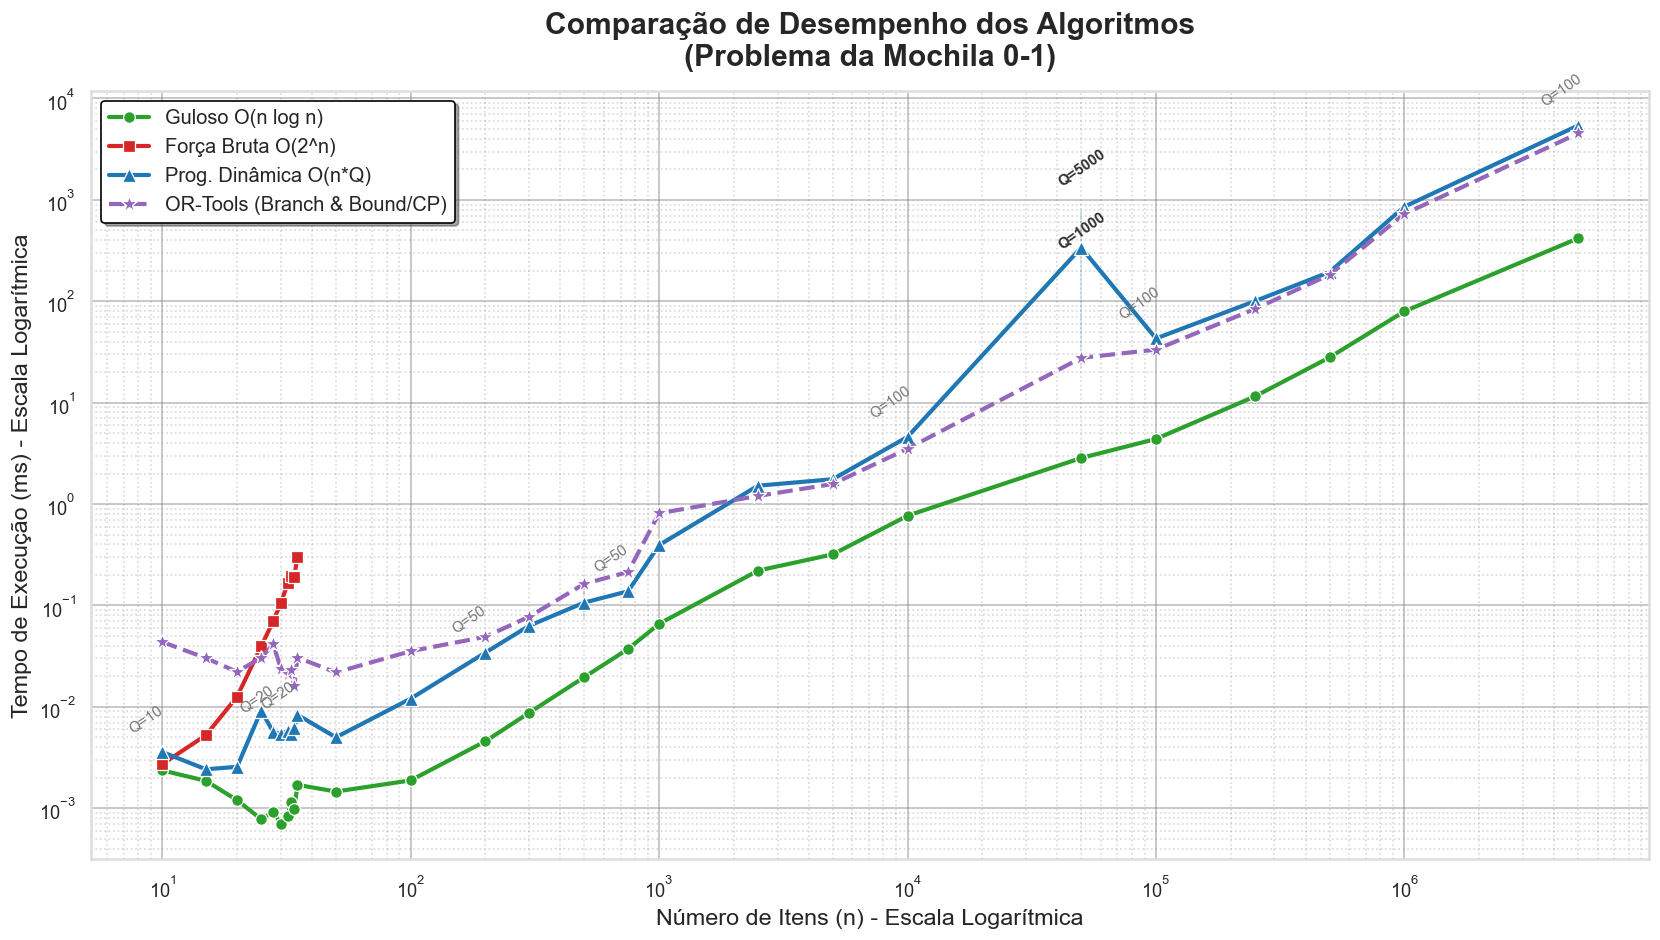

,n,Q,Guloso (ms),Força Bruta (ms),DP (ms),OR-Tools (ms)
0,10,10,0.0024,0.0027,0.0036,0.0436
1,15,10,0.0019,0.0053,0.0024,0.0302
2,20,10,0.0012,0.0126,0.0026,0.0221
3,25,20,0.0008,0.0394,0.0092,0.0305
4,28,20,0.0009,0.0705,0.0056,0.0414
5,30,20,0.0007,0.1055,0.0054,0.0238
6,32,20,0.0008,0.1648,0.0058,0.0209
7,33,20,0.0011,0.1960,0.0054,0.0231
8,34,20,0.0010,0.1927,0.0062,0.0161
9,35,20,0.0017,0.3019,0.0083,0.0306


In [ ]:
if df is not None:
    df['greedy_ms'] = df['greedy_ns_avg'] / 1_000_000
    df['bf_ms'] = df['bruteforce_ns_avg'] / 1_000_000
    df['dp_ms'] = df['dp_ns_avg'] / 1_000_000
    df['ortools_ms'] = df['ortools_ns_avg'] / 1_000_000

    df['bf_ms'] = df['bf_ms'].apply(lambda x: np.nan if x <= 0 else x)

    sns.set_theme(style="white")
    plt.figure(figsize=(14, 8)) 

    sns.lineplot(data=df, x='n', y='greedy_ms', marker='o', 
                 color='#2ca02c', linewidth=2.5, markersize=7, label='Guloso O(n log n)')
    
    sns.lineplot(data=df.dropna(subset=['bf_ms']), x='n', y='bf_ms', marker='s', 
                 color='#d62728', linewidth=2.5, markersize=7, label='Força Bruta O(2^n)')
                 
    sns.lineplot(data=df, x='n', y='dp_ms', marker='^', 
                 color='#1f77b4', linewidth=2.5, markersize=8, label='Prog. Dinâmica O(n*Q)')
                 
    sns.lineplot(data=df, x='n', y='ortools_ms', marker='*', 
                 color='#9467bd', linewidth=2.5, linestyle='--', markersize=10, label='OR-Tools (Híbrido)')

    plt.xscale('log')
    plt.yscale('log')

    plt.title('Comparação de Desempenho dos Algoritmos\n(Problema da Mochila 0-1)', fontsize=18, fontweight='bold', pad=15)
    plt.xlabel('Número de Itens (n) - Escala Logarítmica', fontsize=14)
    plt.ylabel('Tempo de Execução (ms) - Escala Logarítmica', fontsize=14)
    
    plt.grid(True, which="major", ls="-", alpha=0.5, color='gray')
    plt.grid(True, which="minor", ls=":", alpha=0.3, color='gray') 

    for i in range(df.shape[0]):
        n_val = df['n'].iloc[i]
        q_val = df['Q'].iloc[i]
        
        is_highlight = (q_val >= 1000) 
        is_extremities = (i == 0) or (i == len(df) - 1)
        is_spaced_out = (i % 4 == 0)
        
        if is_highlight or is_extremities or is_spaced_out:
            xy_offset = (0, 15) if is_highlight else (-10, 12)
            
            plt.annotate(
                f"Q={q_val}", 
                (n_val, df['dp_ms'].iloc[i]),
                textcoords="offset points", 
                xytext=xy_offset, 
                ha='center',
                fontsize=9,
                fontweight='bold' if is_highlight else 'normal',
                color='#333333' if is_highlight else '#777777',
                rotation=35
            )

    plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, edgecolor='black')
    
    for spine in plt.gca().spines.values():
        spine.set_color('#dddddd')
        spine.set_linewidth(1.5)

    plt.tight_layout()
    plt.show()
    
    cols = ['n', 'Q', 'greedy_ms', 'bf_ms', 'dp_ms', 'ortools_ms']
    final_df = df[cols].rename(columns={
        'greedy_ms': 'Guloso (ms)',
        'bf_ms': 'Força Bruta (ms)',
        'dp_ms': 'DP (ms)',
        'ortools_ms': 'OR-Tools (ms)'
    }).copy()
    
    final_df['Guloso (ms)'] = final_df['Guloso (ms)'].round(4)
    final_df['DP (ms)'] = final_df['DP (ms)'].round(4)
    final_df['OR-Tools (ms)'] = final_df['OR-Tools (ms)'].round(4)
    
    final_df['Força Bruta (ms)'] = final_df['Força Bruta (ms)'].apply(lambda x: f"{x:.4f}" if pd.notna(x) else 'Abortado')
    
    display(final_df)